In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess
import barycenter_functions

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [2]:
# Useful references -------------------------
familiar_group_ids = ["baggy", "bash", "boned", "cargo","five", "grip", "mule", "polio", "rerun", "slate", "slept", "trial", "yeast"] 
unfamiliar_group_ids = ["atom", "brim", "chef", "clerk", "debt", "grid", "lens", "limb", "most","slimy", "swarm", "wok"]
track_pieces_of_interest = ['symmetric_parabolic','t_turn'] # track segments for trial 10 analysis
#track_piece_id = 'symmetric_parabolic'

In [3]:
# Get objects associated with a given subject and their trial
subject_object = subject_dict["baggy"] 
trial_object_ten = subject_object.trials[9]

# Get track objects for later functions...
sym_parab_object = trial_object_ten.pieces['symmetric_parabolic'] # get the track piece object associated to the track piece
t_turn_object = trial_object_ten.pieces['t_turn'] # get the track piece object associated to the track piece

In [4]:
# get trajectories (trimmed for RESETS) for both track segments
sym_parab_familiar_trajectories,sym_parab_unfamiliar_trajectories = barycenter_functions.process_groups(familiar_group_ids,unfamiliar_group_ids,subject_dict, 'symmetric_parabolic')

t_turn_familiar_trajectories,t_turn_unfamiliar_trajectories = barycenter_functions.process_groups(familiar_group_ids,unfamiliar_group_ids,subject_dict, 't_turn')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_trajectories_for_group(condition,group_trajectories,track_piece_object):
    plt.figure(figsize=(12, 8))

    # Plot all subject trajectories in red
    for i, traj in enumerate(group_trajectories[0:12]):
        plt.plot(traj[:, 0], traj[:, 1], lw=2, color='gray',label='Trajectory', alpha=0.6)

    # Get the centerline for reference
    track_piece_center_x, track_piece_center_y = track_piece_object.centerline_df['x'],track_piece_object.centerline_df['y']
    plt.plot(track_piece_center_x, track_piece_center_y, color='black', linestyle='dotted', lw=3, label='Mean Trajectory')

    # Plot the DBA trajectory
    dir_path = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/presentations/r_figures/"
    dba_file_path = dir_path + f"/{condition}_{track_piece_object.id}_DBA_traj_scaled2.csv"
    dba_df = pd.read_csv(dba_file_path)
    plt.plot(dba_df['X'], dba_df['Z'], color='red', lw=4, label='Centerline')


    # Plotting labels
    plt.title(f'Trajectories on Trial 10 for {track_piece_object.id} for {condition} group')
    plt.xlabel('X Position')
    plt.ylabel('Z Position')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()
    #plt.savefig(f"C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/presentations/r_figures/{condition}_{track_piece_object.id}_all_trajectories_and_dba.svg")

In [25]:
# get barycenters
# barycenter_functions.get_barycenter_per_group("Constant Track",sym_parab_object,sym_parab_familiar_trajectories,familiar_group_ids)
# barycenter_functions.get_barycenter_per_group("Variable Track",sym_parab_object,sym_parab_unfamiliar_trajectories,unfamiliar_group_ids)
# barycenter_functions.get_barycenter_per_group("Constant Track",t_turn_object,t_turn_familiar_trajectories,familiar_group_ids)
# barycenter_functions.get_barycenter_per_group("Variable Track",t_turn_object,t_turn_unfamiliar_trajectories,unfamiliar_group_ids)

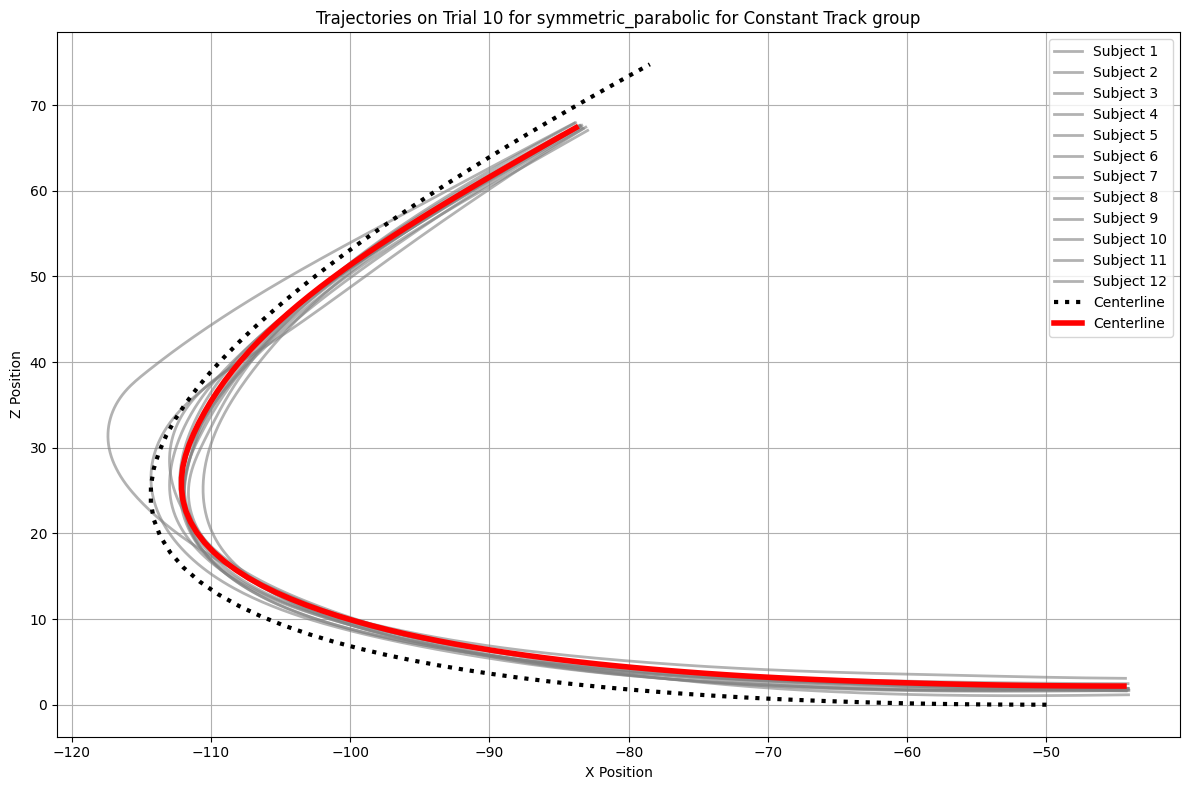

In [26]:
# To visualize all trajectories... 
plot_trajectories_for_group("Constant Track",sym_parab_familiar_trajectories,sym_parab_object)

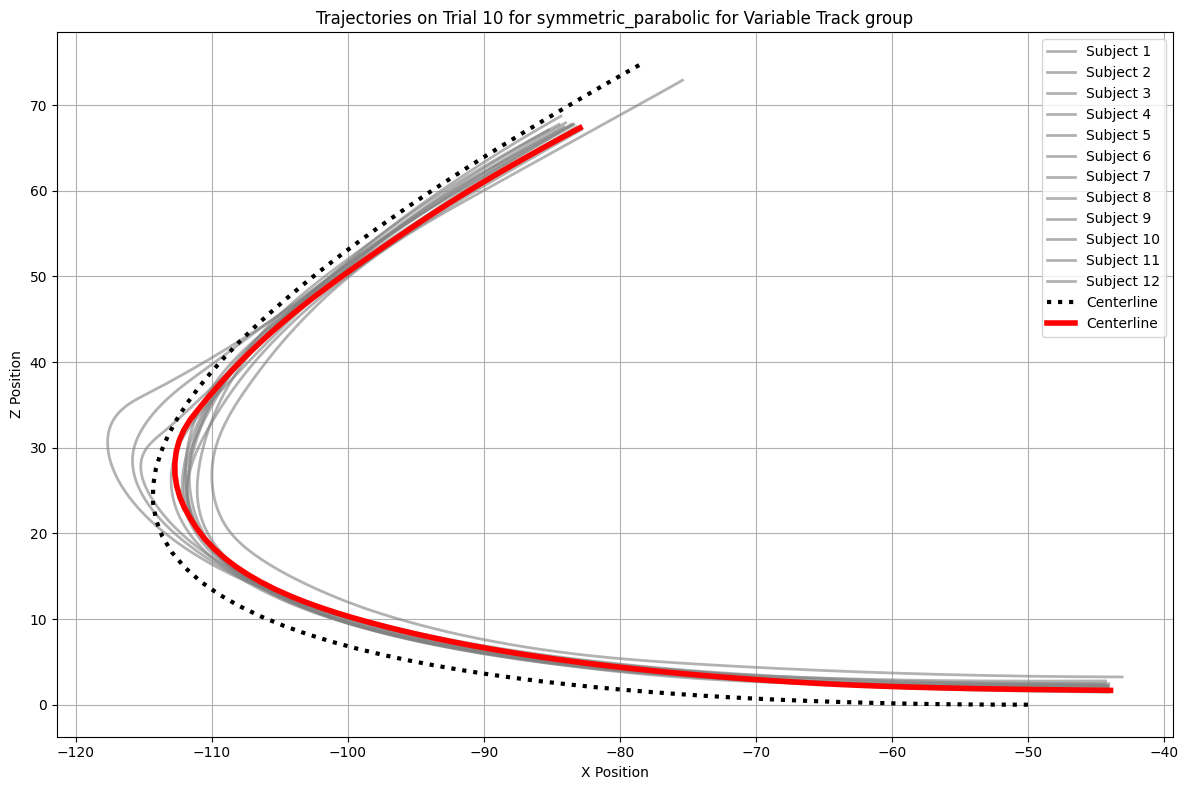

In [27]:
plot_trajectories_for_group("Variable Track",sym_parab_unfamiliar_trajectories,sym_parab_object)

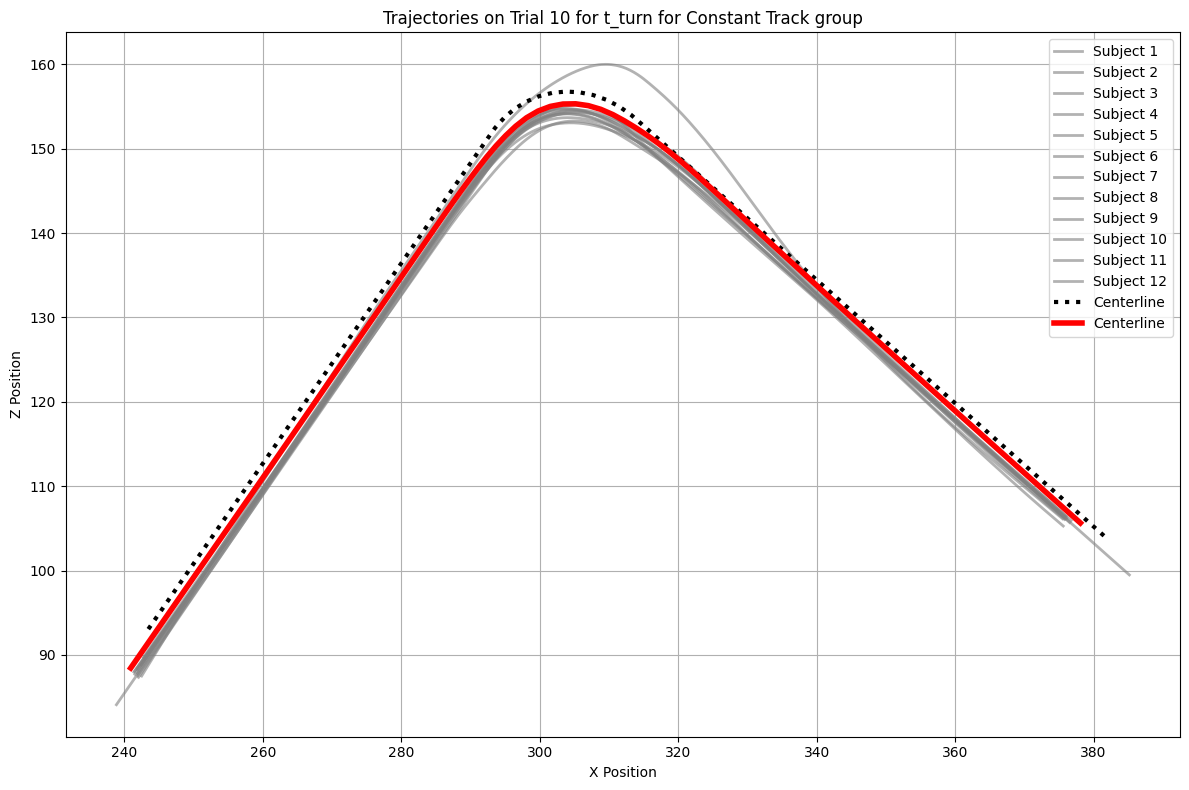

In [28]:
plot_trajectories_for_group("Constant Track",t_turn_familiar_trajectories,t_turn_object)

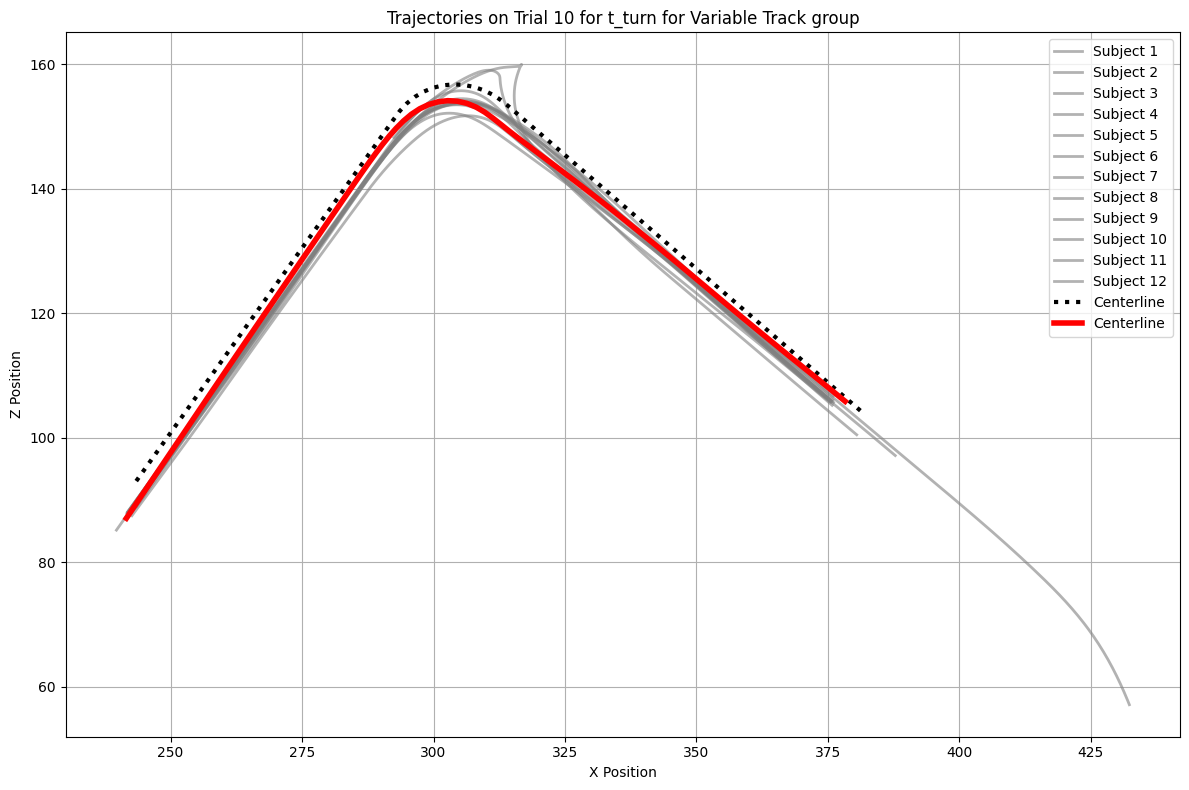

In [29]:
plot_trajectories_for_group("Variable Track",t_turn_unfamiliar_trajectories,t_turn_object)